# Pointwise Evaluation Analysis



This notebook summarizes pointwise evaluation outputs produced by `pointwise_pipeline.py`.
It automatically loads the latest artifacts for both the LLM Grader and BiGGen-Bench datasets,
replicates core metrics, highlights notable examples, and provides utilities for inspecting
specific ranges of prompts and judge responses.


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from metrics import analyze_pointwise_results, render_analysis

plt.style.use("ggplot")


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"

DATASET_CONFIG = {
    "llm_grader": {
        "display": "LLM Grader",
        "result": RESULTS_DIR / "llm_grader" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "llm_grader" / "summary.json",
    },
    "biggen_bench": {
        "display": "BiGGen-Bench",
        "result": RESULTS_DIR / "biggen_bench" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "biggen_bench" / "summary.json",
    },
    "flask": {
        "display": "FLASK",
        "result": RESULTS_DIR / "flask" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "flask" / "summary.json",
    },
    "mt_bench": {
        "display": "MT-Bench",
        "result": RESULTS_DIR / "mt_bench" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "mt_bench" / "summary.json",
        "optional": True,
    },
    "chatbot_arena": {
        "display": "Chatbot Arena",
        "result": RESULTS_DIR / "chatbot_arena" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "chatbot_arena" / "summary.json",
        "optional": True,
    },
}

DISPLAY_NAMES = {key: cfg["display"] for key, cfg in DATASET_CONFIG.items()}


def load_records(path: Path) -> List[dict]:
    with path.open("r", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def _to_float(value: Any) -> Optional[float]:
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _extract_user_prompt(record: Dict[str, Any]) -> str:
    for message in record.get("prompt", []):
        if isinstance(message, dict) and message.get("role") == "user":
            text = message.get("content") or message.get("text")
            if text:
                return str(text)
    return ""


def _extract_response_text(record: Dict[str, Any]) -> str:
    for message in record.get("response", []):
        if isinstance(message, dict):
            text = message.get("text") or message.get("content")
            if text:
                return str(text)
    return ""


def _squash_text(text: str, limit: int = 600) -> str:
    if not text:
        return "<empty>"
    shortened = text.strip()
    if len(shortened) <= limit:
        return shortened
    return shortened[: limit - 3] + "..."


def records_to_frame(records: List[dict], dataset_key: str) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for idx, record in enumerate(records):
        metadata = record.get("metadata") or {}
        if not isinstance(metadata, dict):
            metadata = {}
        result_obj = record.get("result") or {}
        model_score = _to_float(result_obj.get("score"))
        human_scores_raw = metadata.get("human_scores") or []
        human_scores: List[float] = []
        for value in human_scores_raw:
            candidate = _to_float(value)
            if candidate is not None:
                human_scores.append(candidate)
        human_mean = float(np.mean(human_scores)) if human_scores else math.nan
        score_diff = math.nan
        if model_score is not None and not math.isnan(human_mean):
            score_diff = model_score - human_mean

        full_prompt = _extract_user_prompt(record)
        prompt_excerpt = _squash_text(full_prompt)
        full_response = _extract_response_text(record)
        response_excerpt = _squash_text(full_response)

        rows.append(
            {
                "idx": idx,
                "id": record.get("id"),
                "dataset": metadata.get("dataset", dataset_key),
                "model_score": model_score if model_score is not None else math.nan,
                "max_score": _to_float(metadata.get("max_score")),
                "human_mean": human_mean,
                "human_scores": human_scores,
                "human_score_source": metadata.get("human_score_source"),
                "human_score_provider": metadata.get("human_score_provider"),
                "score_diff": score_diff,
                "abs_diff": abs(score_diff) if not math.isnan(score_diff) else math.nan,
                "user_prompt": prompt_excerpt,
                "prompt_excerpt": prompt_excerpt,
                "prompt_full": full_prompt,
                "student_answer": metadata.get("student_answer"),
                "judge_response": response_excerpt,
                "judge_response_full": full_response,
                "sections": metadata.get("sections", {}),
                "result": result_obj,
            }
        )
    frame = pd.DataFrame(rows)
    return frame


def build_dataset_summary(dataset_key: str, cfg: Dict[str, Any]) -> Dict[str, Any]:
    result_path = cfg.get("result")
    meta_path = cfg.get("meta")
    if result_path is None or not result_path.exists():
        raise FileNotFoundError(
            f"Could not locate result file for '{dataset_key}' at {result_path}."
        )

    meta_payload: Dict[str, Any] = {}
    if meta_path is not None and meta_path.exists():
        meta_payload = json.loads(meta_path.read_text(encoding="utf-8"))

    analysis_sections = analyze_pointwise_results(
        result_path,
        meta_path=meta_path,
        include_meta=True,
    )

    records = load_records(result_path)
    frame = records_to_frame(records, dataset_key)
    model_scores = frame["model_score"].dropna()
    human_scores = frame["human_mean"].dropna()
    max_scores = frame["max_score"].dropna()

    stats = {
        "dataset": DISPLAY_NAMES.get(dataset_key, dataset_key),
        "examples": int(len(frame)),
        "with_human": int(frame["human_mean"].notna().sum()),
        "model_mean": float(model_scores.mean()) if not model_scores.empty else math.nan,
        "model_std": float(model_scores.std()) if not model_scores.empty else math.nan,
        "human_mean": float(human_scores.mean()) if not human_scores.empty else math.nan,
        "max_score": float(max_scores.max()) if not max_scores.empty else math.nan,
        "pearson_corr": meta_payload.get("pearson_corr"),
        "result_path": result_path,
        "meta_path": meta_path,
    }

    diff_scores = frame["score_diff"].dropna()
    diff_std = float(diff_scores.std()) if not diff_scores.empty else 0.0
    diff_mean = float(diff_scores.mean()) if not diff_scores.empty else 0.0
    if diff_scores.empty:
        outliers = frame.iloc[0:0]
    else:
        threshold = diff_mean + 2 * diff_std
        outliers = frame[frame["abs_diff"] > threshold]

    top_examples = frame.sort_values("model_score", ascending=False).head(5)
    bottom_examples = frame.sort_values("model_score", ascending=True).head(5)
    largest_diffs = frame.sort_values("abs_diff", ascending=False).head(5)

    summary = {
        "key": dataset_key,
        "display_name": DISPLAY_NAMES.get(dataset_key, dataset_key),
        "config": cfg,
        "result_path": result_path,
        "meta_path": meta_path,
        "records": records,
        "meta": meta_payload,
        "analysis": analysis_sections,
        "analysis_report": render_analysis(analysis_sections),
        "dataframe": frame,
        "stats": stats,
        "top_examples": top_examples[["id", "model_score", "human_mean", "score_diff"]],
        "bottom_examples": bottom_examples[["id", "model_score", "human_mean", "score_diff"]],
        "largest_diffs": largest_diffs[["id", "model_score", "human_mean", "score_diff"]],
        "outliers": outliers[["id", "model_score", "human_mean", "score_diff"]],
    }
    return summary


In [ ]:
DATASET_SUMMARIES: Dict[str, Dict[str, Any]] = {}
for key, cfg in DATASET_CONFIG.items():
    if cfg.get("optional") and not cfg["result"].exists():
        display(Markdown(f':information_source: Skipping optional dataset `{cfg['display']}` – no results found.'))
        continue
    try:
        DATASET_SUMMARIES[key] = build_dataset_summary(key, cfg)
    except FileNotFoundError as exc:
        display(Markdown(f":warning: {exc}"))

AVAILABLE_DATASETS = list(DATASET_SUMMARIES.keys())
if not AVAILABLE_DATASETS:
    raise RuntimeError("No datasets were loaded. Generate evaluation results before running this notebook.")


/nfs/roberts/project/pi_ac3458/vl298/Prompt-Perturbation/metrics.py:238: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = spearmanr(judges, humans)


## Dataset Overview


In [ ]:
overview_rows: List[Dict[str, Any]] = []
for key, payload in DATASET_SUMMARIES.items():
    stats = payload["stats"]
    overview_rows.append(
        {
            "Dataset": stats["dataset"],
            "Examples": stats["examples"],
            "With Human Scores": stats["with_human"],
            "Model Mean": stats["model_mean"],
            "Model Std": stats["model_std"],
            "Human Mean": stats["human_mean"],
            "Max Score": stats["max_score"],
            "Pearson Corr": stats["pearson_corr"],
        }
    )

overview_df = pd.DataFrame(overview_rows).set_index("Dataset")
display(overview_df)


,Examples,With Human Scores,Model Mean,Model Std,Human Mean,Max Score,Pearson Corr
Dataset,,,,,,,
LLM Grader,240,240,2.86875,6.057816,13.627778,40.0,-0.033999
BiGGen-Bench,765,695,0.00000,0.000000,5.000000,5.0,NaN


### LLM Grader

Result file: `ReIFE/results/llm_grader_pointwise.dummy_api.base_pointwise.pointwise_vanilla.jsonl`

Meta file: `ReIFE/results/llm_grader_pointwise.dummy_api.base_pointwise.pointwise_vanilla.meta.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /nfs/roberts/project/pi_ac3458/vl298/Prompt-Perturbation/ReIFE/results
                            | /llm_grader_pointwise.dummy_api.base_pointwise.pointwise_vanilla.jsonl
examples_in_file            | 240                                                                   
examples_with_human_scores  | 240                                                                   
examples_with_perturbations | 240                                                                   
meta_pearson_corr           | -0.0340                                                               
meta_file                   | /nfs/roberts/project/pi_ac3458/vl298/Prompt-Perturbation/ReIFE/results
                            | /llm_grader_pointwise.dummy_api.base_pointwise.pointwise_vanilla.meta.
                            | json                                                                  

Perturbation Dispersion
-------------------------------------
Metric                      | Value  
----------------------------+--------
examples_with_perturbations | 240    
total_perturbed_scores      | 240    
overall_mean_perturbed      | 2.7875 
overall_variance_perturbed  | 35.2224
overall_std_perturbed       | 5.9348 
mean_variance_per_example   | 0.0000 
mean_std_per_example        | 0.0000 

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 240   
mean_MAD_O         | 0.1625
mean_RMSD_O        | 0.1625
mean_MAD_O_norm    | 0.0088
mean_RMSD_O_norm   | 0.0088

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 240   
aSDR            | 0.0041
RMSDR           | 0.0203

Human Alignment
----------------------------
Metric             | Value  
-------------------+--------
examples_evaluated | 240    
pearson_r          | -0.0340
pearson_p          | 0.6002 
spearman_rho       | -0.0456
spearman_p         | 0.4823 
cohen_kappa        | 0.0404 
````

**Top scoring examples**

...

,id,model_score,human_mean,score_diff
48,q2-9,0.0,16.000000,-16.000000
49,q2-10,0.0,16.000000,-16.000000
50,q2-11,0.0,5.333333,-5.333333
51,q2-12,0.0,14.666667,-14.666667
52,q2-13,0.0,13.333333,-13.333333


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
207,q6-8,0.0,40.0,-40.0
217,q6-18,0.0,37.5,-37.5
223,q6-24,0.0,37.5,-37.5
219,q6-20,0.0,37.5,-37.5
224,q6-25,0.0,37.5,-37.5


**Potential outliers**

,id,model_score,human_mean,score_diff
6,q1-7,19.0,6.000000,13.000000
22,q1-23,19.0,6.666667,12.333333
33,q1-34,19.0,6.000000,13.000000
35,q1-36,19.0,5.000000,14.000000
40,q2-1,0.0,16.000000,-16.000000
...,...,...,...,...
233,q6-34,0.0,24.500000,-24.500000
236,q6-37,0.0,37.500000,-37.500000
237,q6-38,0.0,17.500000,-17.500000
238,q6-39,0.0,17.500000,-17.500000


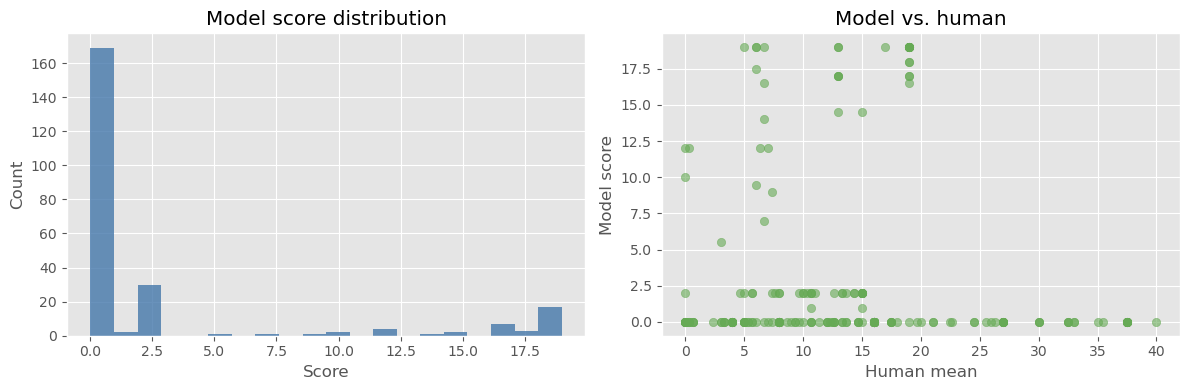

### BiGGen-Bench

Result file: `ReIFE/results/biggen_bench_pointwise.dummy_api.base_pointwise.pointwise_vanilla.jsonl`

Meta file: `ReIFE/results/biggen_bench_pointwise.dummy_api.base_pointwise.pointwise_vanilla.meta.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /nfs/roberts/project/pi_ac3458/vl298/Prompt-Perturbation/ReIFE/results
                            | /biggen_bench_pointwise.dummy_api.base_pointwise.pointwise_vanilla.jso
                            | nl                                                                    
examples_in_file            | 765                                                                   
examples_with_human_scores  | 695                                                                   
examples_with_perturbations | 765                                                                   
meta_file                   | /nfs/roberts/project/pi_ac3458/vl298/Prompt-Perturbation/ReIFE/results
                            | /biggen_bench_pointwise.dummy_api.base_pointwise.pointwise_vanilla.met
                            | a.json                                                                

Perturbation Dispersion
------------------------------------
Metric                      | Value 
----------------------------+-------
examples_with_perturbations | 765   
total_perturbed_scores      | 765   
overall_mean_perturbed      | 0.0000
overall_variance_perturbed  | 0.0000
overall_std_perturbed       | 0.0000
mean_variance_per_example   | 0.0000
mean_std_per_example        | 0.0000

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 765   
mean_MAD_O         | 0.0000
mean_RMSD_O        | 0.0000
mean_MAD_O_norm    | 0.0000
mean_RMSD_O_norm   | 0.0000

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 765   
aSDR            | 0.0000
RMSDR           | 0.0000

Human Alignment
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 695   
pearson_r          | nan   
pearson_p          | nan   
spearman_rho       | nan   
spearman_p         | nan   
cohen_kappa        | 0.0000
````

**Top scoring examples**

...

,id,model_score,human_mean,score_diff
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0
1,grounding_demo_vs_instruction_1,0.0,5.0,-5.0
2,grounding_demo_vs_instruction_2,0.0,5.0,-5.0
3,grounding_demo_vs_instruction_3,0.0,5.0,-5.0
4,grounding_demo_vs_instruction_4,0.0,5.0,-5.0


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0
1,grounding_demo_vs_instruction_1,0.0,5.0,-5.0
2,grounding_demo_vs_instruction_2,0.0,5.0,-5.0
3,grounding_demo_vs_instruction_3,0.0,5.0,-5.0
4,grounding_demo_vs_instruction_4,0.0,5.0,-5.0


**Potential outliers**

,id,model_score,human_mean,score_diff
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0
1,grounding_demo_vs_instruction_1,0.0,5.0,-5.0
2,grounding_demo_vs_instruction_2,0.0,5.0,-5.0
3,grounding_demo_vs_instruction_3,0.0,5.0,-5.0
4,grounding_demo_vs_instruction_4,0.0,5.0,-5.0
...,...,...,...,...
760,tool_usage_web_browsing_5,0.0,5.0,-5.0
761,tool_usage_web_browsing_6,0.0,5.0,-5.0
762,tool_usage_web_browsing_7,0.0,5.0,-5.0
763,tool_usage_web_browsing_8,0.0,5.0,-5.0


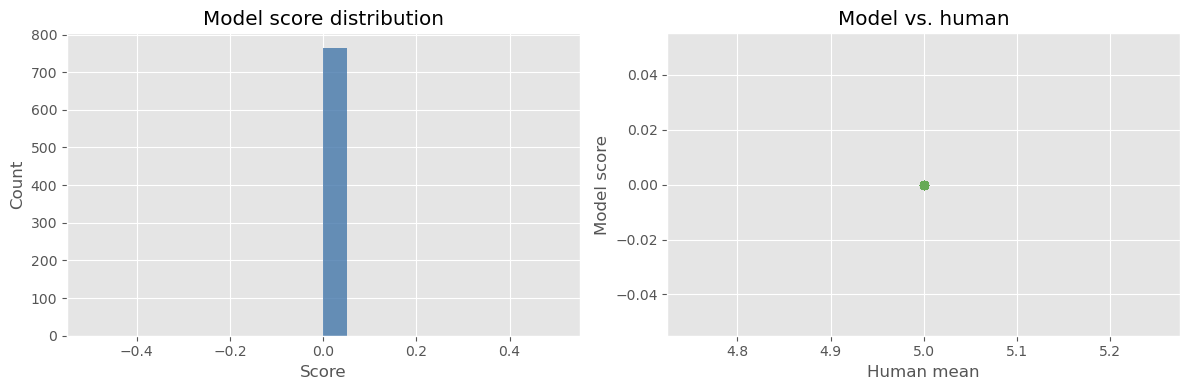

In [ ]:
for key, payload in DATASET_SUMMARIES.items():
    display(Markdown(f"### {payload['display_name']}"))
    result_rel = payload["stats"]["result_path"].relative_to(PROJECT_ROOT)
    meta_path = payload["stats"].get("meta_path")
    meta_rel = meta_path.relative_to(PROJECT_ROOT) if meta_path else "<missing>"
    display(Markdown(f"Result file: `{result_rel}`"))
    display(Markdown(f"Meta file: `{meta_rel}`"))
    display(Markdown("````\n" + payload["analysis_report"] + "\n````"))
    display(Markdown("**Top scoring examples**"))
    display(payload["top_examples"])
    display(Markdown("**Lowest scoring examples**"))
    display(payload["bottom_examples"])
    display(Markdown("**Largest deviations vs. human averages**"))
    display(payload["largest_diffs"])
    if not payload["outliers"].empty:
        display(Markdown("**Potential outliers**"))
        display(payload["outliers"])

    frame = payload["dataframe"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    scores = frame["model_score"].dropna()
    axes[0].hist(scores, bins=20, color="#4477AA", alpha=0.8)
    axes[0].set_title("Model score distribution")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Count")

    paired = frame.dropna(subset=["human_mean", "model_score"])
    if not paired.empty:
        axes[1].scatter(
            paired["human_mean"], paired["model_score"], alpha=0.6, color="#66AA55"
        )
        axes[1].set_xlabel("Human mean")
        axes[1].set_ylabel("Model score")
        axes[1].set_title("Model vs. human")
    else:
        axes[1].text(0.5, 0.5, "No human scores", ha="center", va="center")
        axes[1].set_axis_off()
    plt.tight_layout()
    plt.show()


In [ ]:
def subset(start_idx: int, end_idx: int, dataset_key: str = "llm_grader") -> None:
    if dataset_key not in DATASET_SUMMARIES:
        display(Markdown(f":warning: Dataset `{dataset_key}` is not available."))
        return

    payload = DATASET_SUMMARIES[dataset_key]
    frame = payload["dataframe"]
    window = frame.iloc[start_idx:end_idx]
    if window.empty:
        display(Markdown("No examples in the requested range."))
        return

    display(Markdown(f"#### Examples {start_idx}–{end_idx} ({payload['display_name']})"))
    display(window[["id", "model_score", "human_mean", "score_diff"]])

    indices = np.arange(len(window))
    model_vals = window["model_score"].to_numpy()
    human_vals = window["human_mean"].fillna(0.0).to_numpy()

    fig, ax = plt.subplots(figsize=(8, 4))
    width = 0.35
    ax.bar(indices - width / 2, model_vals, width=width, label="Model")
    ax.bar(indices + width / 2, human_vals, width=width, label="Human")
    ax.set_xticks(indices)
    ax.set_xticklabels(window["id"], rotation=45, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Model vs. human scores")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for _, row in window.iterrows():
        display(Markdown(f"##### {row['id']}"))
        display(Markdown(
            f"Model score: **{row['model_score']}** | Human mean: **{row['human_mean']}**"
        ))
        provenance = row.get("human_score_source")
        provider = row.get("human_score_provider")
        if provenance or provider:
            detail = provenance or "unknown"
            if provider:
                detail = f"{detail} (provider: {provider})"
            display(Markdown(f"Score provenance: `{detail}`"))
        prompt_text = row.get("prompt_full") or row.get("user_prompt", "")
        display(Markdown("**Prompt**"))
        display(Markdown(f"````\n{prompt_text}\n````"))
        display(Markdown("**Judge response**"))
        response_text = row.get("judge_response_full") or row.get("judge_response", "")
        display(Markdown(f"````\n{response_text}\n````"))


#### Examples 0–1 (LLM Grader)

,id,model_score,human_mean,score_diff
0,q1-1,12.0,7.0,5.0


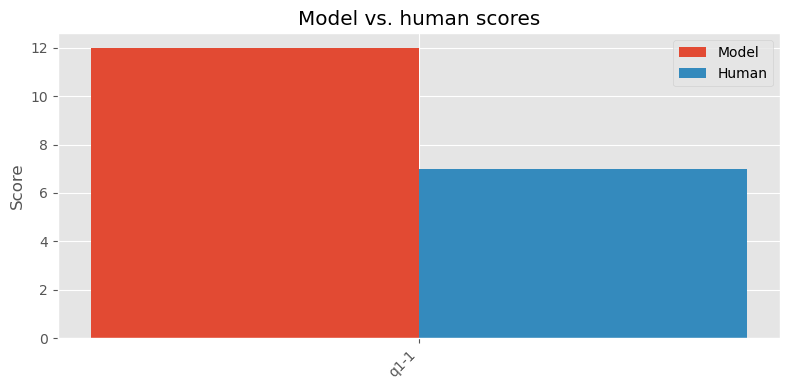

##### q1-1

Model score: **12.0** | Human mean: **7.0**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are a meticulous teaching assistant who grades student responses according to the provided rubric and reference materials.

### Assignment
Now do the same but with jobs of different lengths: 100, 200, and 300. The commands are (./scheduler.py -p SJF -l 100,200,300) and (./scheduler.py -p FIFO -l 100,200,300). Compute the response time and turnaround time for SJF and FIFO? What if you change the order of the job length? Try different orders to find the difference.

### Rubric (Student-Facing)
1.For correct “Average reponse time and Turnaround time” for SJF (6.5 points)
2.For correct “Average reponse time and Turnaround time” for FIFO (6.5 points)
3.For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points) 
4.For correct explain “the results for FIFO policy in different orders will change.” (3 points)

### Instructor Criteria
case1: 
• For correct “Average reponse time and Turnaround time” for SJF (6.5 points)
• For correct “Average reponse time and Turnaround time” for FIFO (6.5 points)
• For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points) 
• For correct explain “the results for FIFO policy in different orders will change.” (3 points) 
case2: 
• For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points)  and explain the reason (6.5). 
• For correct explain “the results for FIFO policy in different orders will change.” (3 points) and explain the reason (6.5).

### Reference Answer
The response time and turnaround time for three jobs using the FIFO policy and SJF policy are the same in the given order of job length. If we change the order of job length, response time and turnaround time for the SJF policy should remain the same.
However, the results for FIFO policy in different orders will change. In particular, if we run these jobs in order 300, 200, 100, it makes FIFO perform poorly (the average response time is 266.67, and turnaround time is 466.67).

### Maximum Score
19

### Reference Materials
# scheduler.py
#! /usr/bin/env python

import sys
from optparse import OptionParser
import random

parser = OptionParser()
parser.add_option("-s", "--seed", default=0, help="the random seed",
                  action="store", type="int", dest="seed")
parser.add_option("-j", "--jobs", default=3, help="number of jobs in the system",
                  action="store", type="int", dest="jobs")
parser.add_option("-l", "--jlist", default="", help="instead of random jobs, provide a comma-separated list of run times",
                  action="store", type="string", dest="jlist")
parser.add_option("-m", "--maxlen", default=10, help="max length of job",
                  action="store", type="int", dest="maxlen")
parser.add_option("-p", "--policy", default="FIFO", help="sched policy to use: SJF, FIFO, RR",
                  action="store", type="string", dest="policy")
parser.add_option("-q", "--quantum", help="length of time slice for RR policy", default=1,
                  action="store", type="int", dest="quantum")
parser.add_option("-c", help="compute answers for me", action="store_true", default=False, dest="solve")

(options, args) = parser.parse_args()

random.seed(options.seed)

print 'ARG policy', options.policy
if options.jlist == '':
    print 'ARG jobs', options.jobs
    print 'ARG maxlen', options.maxlen
    print 'ARG seed', options.seed
else:
    print 'ARG jlist', options.jlist

print ''

print 'Here is the job list, with the run time of each job: '

import operator

joblist = []
if options.jlist == '':
    for jobnum in range(0,options.jobs):
        runtime = int(options.maxlen * random.random()) + 1
        joblist.append([jobnum, runtime])
        print '  Job', jobnum, '( length = ' + str(runtime) + ' )'
else:
    jobnum = 0
    for runtime in options.jlist.split(','):
        joblist.append([jobnum, float(runtime)])
        jobnum += 1
    for job in joblist:
        print '  Job', job[0], '( length = ' + str(job[1]) + ' )'
print '\n'

if options.solve == True:
    print '** Solutions **\n'
    if options.policy == 'SJF':
        joblist = sorted(joblist, key=operator.itemgetter(1))
        options.policy = 'FIFO'

    if options.policy == 'FIFO':
        thetime = 0
        print 'Execution trace:'
        for job in joblist:
            print '  [ time %3d ] Run job %d for %.2f secs ( DONE at %.2f )' % (thetime, job[0], job[1], thetime + job[1])
            thetime += job[1]

        print '\nFinal statistics:'
        t     = 0.0
        count = 0
        turnaroundSum = 0.0
        waitSum       = 0.0
        responseSum   = 0.0
        for tmp in joblist:
            jobnum  = tmp[0]
            runtime = tmp[1]

            response   = t
            turnaround = t + runtime
            wait       = t
            print '  Job %3d -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f' % (jobnum, response, turnaround, wait)
            responseSum   += response
            turnaroundSum += turnaround
            waitSum       += wait
            t += runtime
            count = count + 1
        print '\n  Average -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f\n' % (responseSum/count, turnaroundSum/count, waitSum/count)

    if options.policy == 'RR':
        print 'Execution trace:'
        turnaround = {}
        response = {}
        lastran = {}
        wait = {}
        quantum  = float(options.quantum)
        jobcount = len(joblist)
        for i in range(0,jobcount):
            lastran[i] = 0.0
            wait[i] = 0.0
            turnaround[i] = 0.0
            response[i] = -1

        runlist = []
        for e in joblist:
            runlist.append(e)

        thetime  = 0.0
        while jobcount > 0:
            # print '%d jobs remaining' % jobcount
            job = runlist.pop(0)
            jobnum  = job[0]
            runtime = float(job[1])
            if response[jobnum] == -1:
                response[jobnum] = thetime
            currwait = thetime - lastran[jobnum]
            wait[jobnum] += currwait
            if runtime > quantum:
                runtime -= quantum
                ranfor = quantum
                print '  [ time %3d ] Run job %3d for %.2f secs' % (thetime, jobnum, ranfor)
                runlist.append([jobnum, runtime])
            else:
                ranfor = runtime;
                print '  [ time %3d ] Run job %3d for %.2f secs ( DONE at %.2f )' % (thetime, jobnum, ranfor, thetime + ranfor)
                turnaround[jobnum] = thetime + ranfor
                jobcount -= 1
            thetime += ranfor
            lastran[jobnum] = thetime

        print '\nFinal statistics:'
        turnaroundSum = 0.0
        waitSum       = 0.0
        responseSum   = 0.0
        for i in range(0,len(joblist)):
            turnaroundSum += turnaround[i]
            responseSum += response[i]
            waitSum += wait[i]
            print '  Job %3d -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f' % (i, response[i], turnaround[i], wait[i])
        count = len(joblist)

        print '\n  Average -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f\n' % (responseSum/count, turnaroundSum/count, waitSum/count)

    if options.policy != 'FIFO' and options.policy != 'SJF' and options.policy != 'RR':
        print 'Error: Policy', options.policy, 'is not available.'
        sys.exit(0)
else:
    print 'Compute the turnaround time, response time, and wait time for each job.'
    print 'When you are done, run this program again, with the same arguments,'
    print 'but with -c, which will thus provide you with the answers. You can use'
    print '-s <somenumber> or your own job list (-l 10,15,20 for example)'
    print 'to generate different problems for yourself.'
    print ''

# Student Answer:
When changing the order of the length to 
“ ./scheduler.py -p SJF -l 300,200,100 ”, the scheduler will execute the last jobs first because it has the shortest length, then the execute the second and last the first. However, the change of the order of the jobs length will still execute from the first to the last job as it is FIFO.

# Output Format:
Return a single integer score only.
````

**Judge response**

````
12
````

In [ ]:
subset(0, 1, "llm_grader")


#### Examples 0–1 (BiGGen-Bench)

,id,model_score,human_mean,score_diff
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0


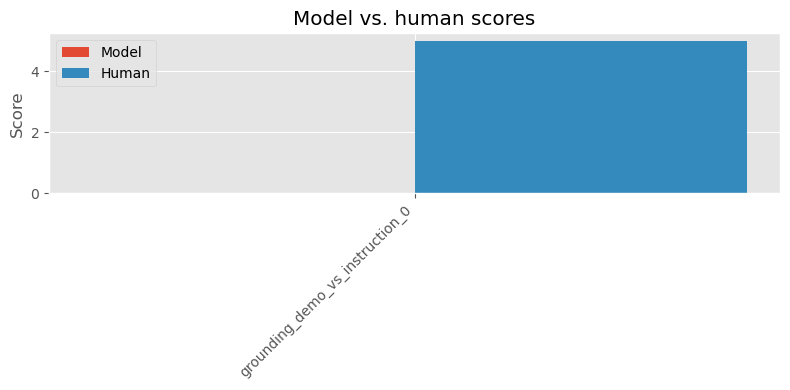

##### grounding_demo_vs_instruction_0

Model score: **0.0** | Human mean: **5.0**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
Translate the given sentence to English.

Source: La pomme est colorée en rouge.
Destination: Der Apfel ist rot gefärbt.
Source: La Tour Eiffel est située en France.
Destination: Der Eiffelturm befindet sich in Frankreich.
Source: Je voudrais un expresso, s'il vous plaît

### System Prompt
You are a helpful, respectful and honest assistant.

### Reference Answer
Destination: I'd like an espresso, please.

### Score Rubric
Criteria:
Does the response accurately reflect grounding to either the demonstration or instruction while addressing the language of translation?

Score 1:
The response is in German, accurately translating the source sentence 'Je voudrais un expresso, s'il vous plaît' into German, aligning with the demonstration's pattern of translating French to German, disregarding the instruction to translate to English.

Score 2:
The response is in German, translating the source sentence but with minor inaccuracies or alterations in meaning, showing partial alignment with the demonstration's language choice but not fully adhering to the translation accuracy.

Score 3:
The response acknowledges the conflict between the demonstration and instruction, attempting to explain or justify the choice of translation language or the approach taken, without fully committing to either English or German.

Score 4:
The response is in English, translating the source sentence but with minor inaccuracies or alterations in meaning, showing alignment with the instruction to translate to English, but not fully adhering to the translation accuracy.

Score 5:
The response is in English, accurately translating the source sentence 'Je voudrais un expresso, s'il vous plaît' into English, aligning with the instruction to translate to English, disregarding the demonstration's pattern of translating to German.

### Maximum Score
5

# Student Answer:
Hello World!

# Output Format:
Return a single integer score only.
````

**Judge response**

````
0
````

In [ ]:
subset(0, 1, "biggen_bench")

In [ ]:
subset(0, 1, "flask")

NameError: name 'subset' is not defined

In [ ]:
subset(0, 1, "mt_bench")

In [ ]:
subset(0, 1, "chatbot_arena")